<a href="https://colab.research.google.com/github/shivamtyagi577/E-commerce-Customer-End-to-End-Churn/blob/main/Customer_Churn_Analysis_E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement



## Objective

The goal of this proejct is to analyze customer behaviour and the identify key factors influencing **customer churn**.

## Business Problem

Customer chrun directly impacts revenue.
Understanding why customer leaves enables the business to:
* Improve Retention
* Optimize customer experience
* Increase lifetime value.



## Key Questions
* What drives churn?
* Which customers are high-risk?
* How can the business reduce churn?

# 📌Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

In [2]:
path = '/content/drive/MyDrive/Skills/Projects_Data-Science/E Commerce Dataset.xlsx'
df = pd.read_excel(path,sheet_name = 'E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


# 📌Initial Exploration

* Each row represents a customer
* Target variable : Churn

In [3]:
df.shape

(5630, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [5]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


# 📌Data Cleaning & Preparation

1. Convert churn into categorical
2. Convert columns which are ***int*** type into ***object***
3. Handle missing values (initial check)

**Point No. 2:**

1. **Preventing Mathematical Misinterpretation**

For features like CityTier (1, 2, 3) or Churn (0, 1), the numbers are just labels.

**The Risk:** A model might think that CityTier 3 is "three times more" than CityTier 1, or try to calculate an "average city" of 1.5.

**The Reality:** These are distinct categories. Converting them to an Object (string) forces the model to treat them as separate groups rather than a mathematical sequence.


2. **Handling "Rank" vs. "Value"**

Columns like SatisfactionScore and NumberOfDeviceRegistered are Ordinal Data.

While there is a sequence (5 is higher than 1), the "distance" between a score of 1 and 2 might not be the same as the distance between 4 and 5 in the customer's mind.

By treating them as Objects/Categories, you allow the model to see if a specific score (like "3") has a unique, non-linear impact on churn.

3. **Improving Exploratory Data Analysis (EDA)**

When you run df.describe(), pandas handles Numeric and Object types differently:

Numeric: Gives you Mean, Std Dev, and Percentiles (useless for a 0/1 Churn toggle).

**Object:** Gives you Unique counts, Top value, and Frequency.

4. **Requirement for One-Hot Encoding**

Most machine learning algorithms (like Linear Regression or SVMs) cannot handle categories directly. By converting them to Objects first, you make it easier to use tools like pd.get_dummies() later to transform these into "dummy variables" that the model can actually understand.

In [6]:
df.describe(include='O')

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


In [7]:
for col in df.columns:
  if df[col].dtype == 'object':
    print(str(col) + ' : ' + str(df[col].unique()))
    print(df[col].value_counts())
    print('---------------------------------------------------------------------------------------------------')

PreferredLoginDevice : ['Mobile Phone' 'Phone' 'Computer']
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------
PreferredPaymentMode : ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------
Gender : ['Female' 'Male']
Gender
Male      3384
Female    2246
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------
PreferedOrderCat : ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
PreferedOrderCat
Laptop &

In [8]:
df.select_dtypes(include=np.number).columns

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [9]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [10]:
# As mobile phone and phone are both same so we have merged them
df.loc[df['PreferredLoginDevice']=='Phone', 'PreferredLoginDevice'] = 'Mobile Phone'
df.loc[df['PreferedOrderCat']=='Mobile', 'PreferedOrderCat'] = 'Mobile Phone'

In [11]:
df.describe(include='O')

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,2,7,2,5,3
top,Mobile Phone,Debit Card,Male,Mobile Phone,Married
freq,3996,2314,3384,2080,2986


In [12]:
df.loc[df['PreferredPaymentMode']=='COD', 'PreferredPaymentMode'] = 'Cash on Delivery'
df.loc[df['PreferredPaymentMode']=='CC', 'PreferredPaymentMode'] = 'Credit Card'

In [13]:
df.describe(include='O')

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,2,5,2,5,3
top,Mobile Phone,Debit Card,Male,Mobile Phone,Married
freq,3996,2314,3384,2080,2986


In [14]:
for col in df.columns:
  if df[col].dtype == 'object':
    print(str(col) + ' : ' + str(df[col].unique()))
    print(df[col].value_counts())
    print('---------------------------------------------------------------------------------------------------')

PreferredLoginDevice : ['Mobile Phone' 'Computer']
PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------
PreferredPaymentMode : ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------
Gender : ['Female' 'Male']
Gender
Male      3384
Female    2246
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------
PreferedOrderCat : ['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410

In [15]:
for col in df.columns:
  if df[col].dtype != 'object':
    print(str(col) + ' : ' + str(df[col].unique()))
    print(df[col].value_counts())
    print('---------------------------------------------------------------------------------------------------')

CustomerID : [50001 50002 50003 ... 55628 55629 55630]
CustomerID
55630    1
50001    1
50002    1
50003    1
50004    1
        ..
50019    1
50018    1
50017    1
50016    1
50015    1
Name: count, Length: 5630, dtype: int64
---------------------------------------------------------------------------------------------------
Churn : [1 0]
Churn
0    4682
1     948
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------
Tenure : [ 4. nan  0. 13. 11.  9. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.
  6. 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51.
 61.]
Tenure
1.0     690
0.0     508
8.0     263
9.0     247
7.0     221
10.0    213
5.0     204
4.0     203
3.0     195
11.0    194
6.0     183
12.0    182
13.0    181
14.0    176
2.0     167
15.0    159
16.0    149
19.0    140
18.0    123
20.0    109
17.0    106
23.0     89
21.0     84
22.0     76
24.0     75
28.0     70
30.0     66
27.0     66
26.

In [16]:
df_objectype = df.copy()
for col in df_objectype.columns:
  if col == 'CustomerID':
    continue
  else:
    if df_objectype[col].dtype == 'int':
      df_objectype[col] = df[col].astype(str)

df_objectype.dtypes

,0
CustomerID,int64
Churn,object
Tenure,float64
PreferredLoginDevice,object
CityTier,object
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,object


***Churn, CityTeir, NumberofDeviceRegistered, SatisfcationScore, NumberofAddress, Complain***

has been converted into Object Type.



In [17]:
df_objectype.describe(include='O')

,Churn,PreferredLoginDevice,CityTier,PreferredPaymentMode,Gender,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain
count,5630,5630,5630,5630,5630,5630,5630,5630,5630,5630,5630
unique,2,2,3,5,2,6,5,5,3,15,2
top,0,Mobile Phone,1,Debit Card,Male,4,Mobile Phone,3,Married,2,0
freq,4682,3996,3666,2314,3384,2377,2080,1698,2986,1369,4026


# 📌Missing Value Analysis

In [18]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


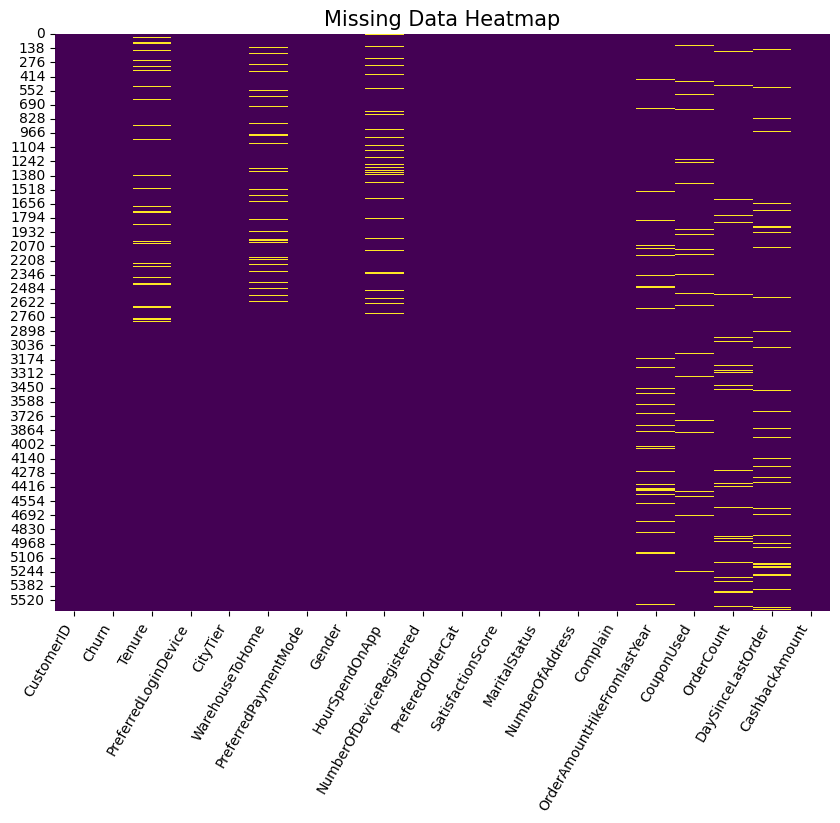

CustomerID                     0.000000
Churn                          0.000000
Tenure                         4.689165
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.458259
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.529307
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
CashbackAmount                 0.000000
dtype: float64


In [19]:
plt.figure(figsize=(10,7.5))
sns.heatmap(df.isnull(),cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap', fontsize = 15)
plt.xticks(rotation = 60, ha='right')
plt.show()

print((df.isnull().sum() / len(df)) * 100)

# 📌Class Imbalance Analysis

**Churn Distribution**

Check whether the dataset is imbalanced

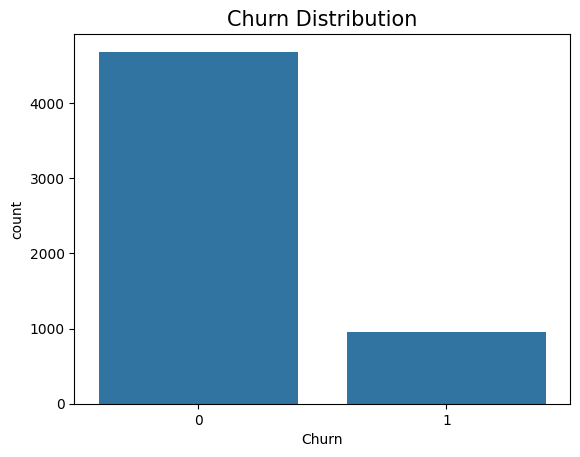

In [20]:
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution', fontsize=15)
plt.show()

In a perfectly balanced dataset, you would see a 50/50 split. Here is how your "Churn" column looks:

* **Class 0 (No Churn):** ~4,682 customers

* **Class 1 (Churn):** ~948 customers


**Why this is a "Moderate" Imbalance**
Your churn rate is approximately 17%. In the world of machine learning:

* **Minority Class: Churn (1)**

* **Majority Class: No Churn (0)**

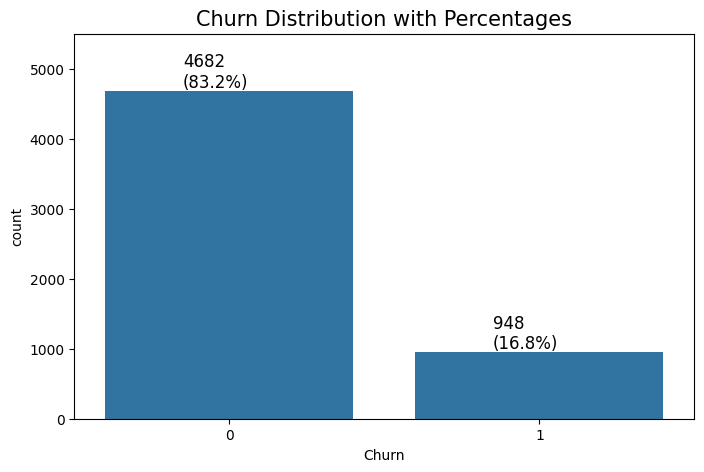

In [21]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Churn')

# Calculate percentages and add labels
total = len(df['Churn'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 50 # Adjust the '+ 50' to move the text up/down
    ax.annotate(f'{int(p.get_height())}\n({percentage})', (x, y), size=12)

plt.title('Churn Distribution with Percentages', fontsize=15)
plt.ylim(0, 5500) # Give some extra room at the top for labels
plt.show()

# 📌 Correlation Analysis (Numerical)

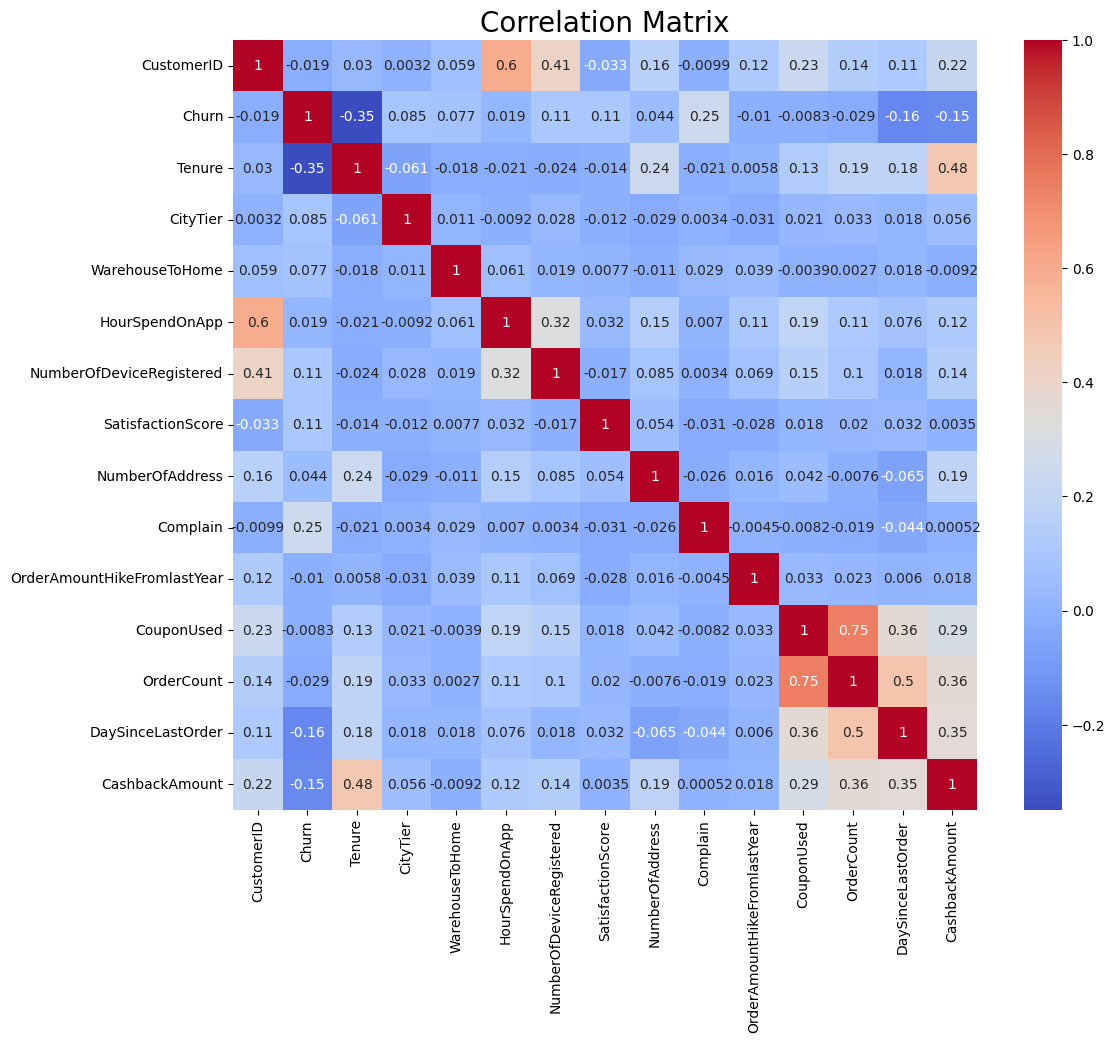

In [22]:
plt.figure(figsize=(12,10))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix', fontsize=20)
plt.show()

# 📌Distribution Analysis

Helps detect skewness and outliers

In [23]:
num_cols = []
for col in df_objectype.columns:
  if col == 'CustomerID':
    continue
  else:
    if df_objectype[col].dtype != 'object':
      num_cols.append(col)

num_cols

['Tenure',
 'WarehouseToHome',
 'HourSpendOnApp',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

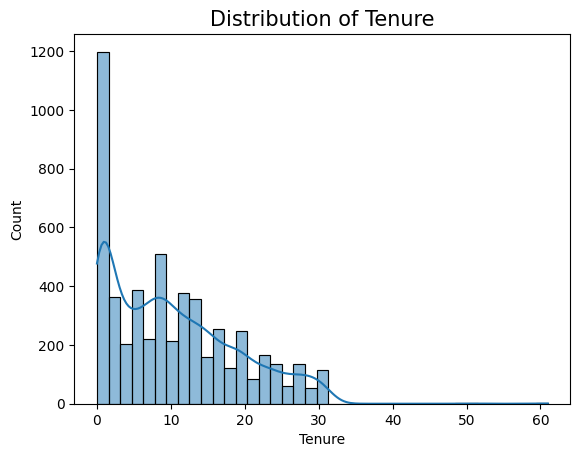

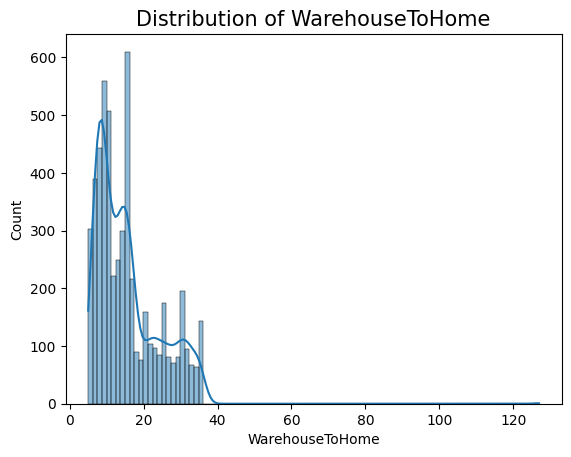

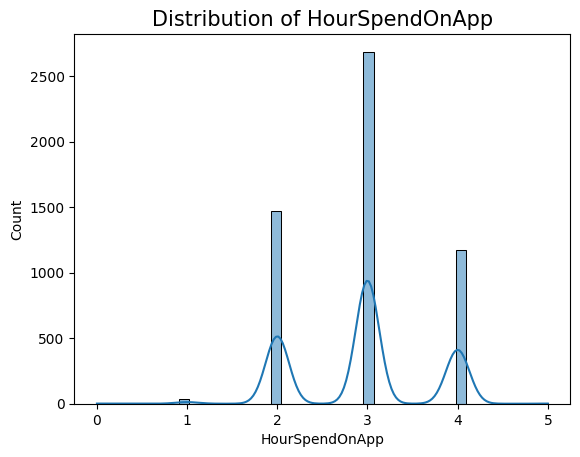

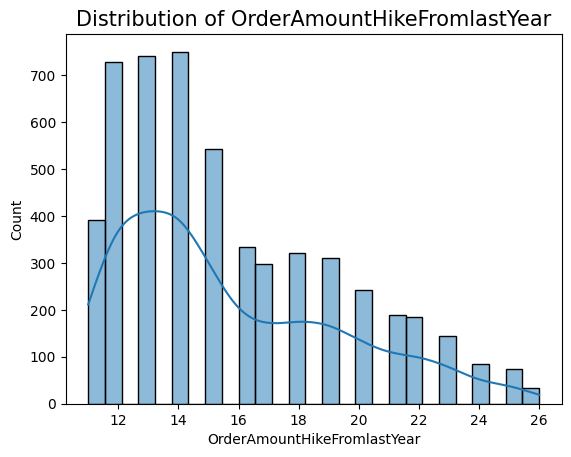

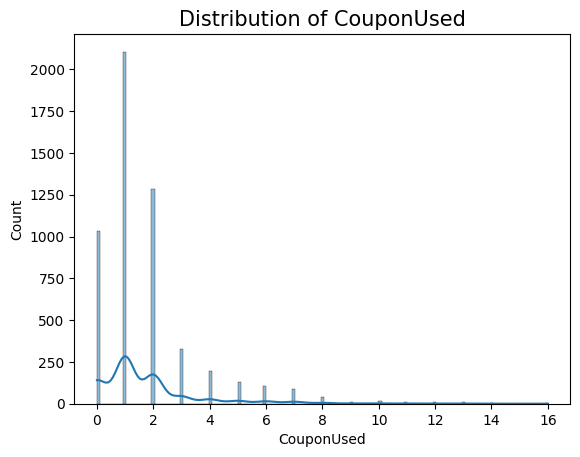

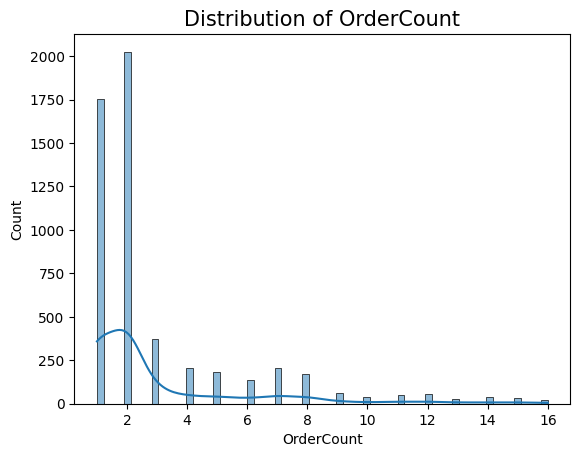

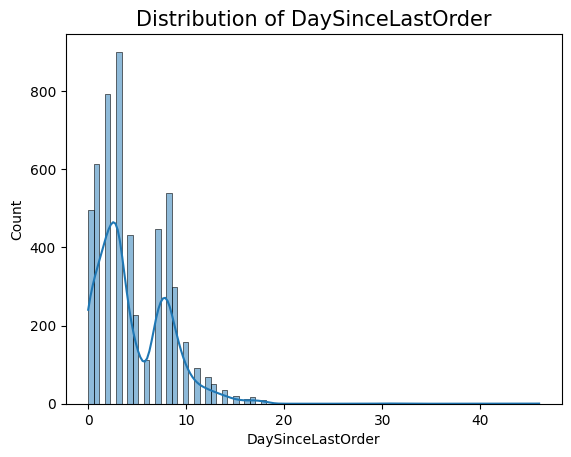

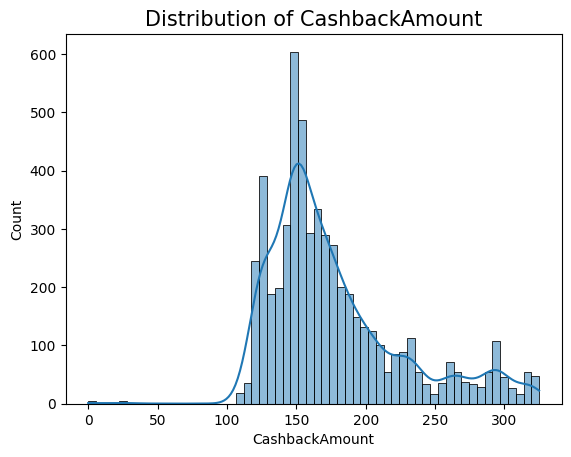

In [24]:
for col in num_cols:
  sns.histplot(df[col], kde=True)
  plt.title(f'Distribution of {col}', fontsize=15)
  plt.show()

## **Distribution Analysis** 📊

**1. Identifying Skewness**

Most of the numerical plots (like **Tenure** or **CashbackAmount**) likely show a Right Skew (a long tail on the right).

* **The Benefit:** If you see that most customers have a tenure of 0–5 months but a few have 60, you know your "**average**" is being pulled up by outliers. This tells you that the **Median is a better representation of your "typical" customer than the Mean.**

**2. Spotting Outliers**

In **WarehouseToHome** or **NumberOfAddress** distributions, you might see small bars very far to the right.

* **The Benefit:** Outliers can "confuse" machine learning models, especially linear ones. Seeing these distributions helps you decide if you need to cap those values (e.g., treating everyone with 20+ addresses as "20") or investigate if they are data entry errors.


**3. Checking "Spread" (Variance)**

If a distribution is very flat, it means the values are all over the place. If it’s a sharp peak, most customers are the same.

* **The Benefit:** Features with very little spread (where 99% of people have the same value) are often useless for prediction and can be dropped to simplify your model.

**4. Validating Scaling Needs**

Algorithms like K-Nearest Neighbors or SVMs are sensitive to the scale of data.

* **The Benefit:** By seeing that CashbackAmount goes up to 300 while SatisfactionScore only goes to 5, you can visually confirm that you'll need to Normalize or Standardize your data before modeling so the "300" doesn't overwhelm the "5."


In [25]:
skewed_data = []
for col in num_cols:
  skewed_data.append([col,df[col].skew()])

skewed_df = pd.DataFrame(skewed_data, columns=['Column','Skew Value'])
skewed_df

,Column,Skew Value
0,Tenure,0.736513
1,WarehouseToHome,1.619154
2,HourSpendOnApp,-0.027213
3,OrderAmountHikeFromlastYear,0.790785
4,CouponUsed,2.545653
5,OrderCount,2.196414
6,DaySinceLastOrder,1.191000
7,CashbackAmount,1.149846


In my specific output, columns like CouponUsed (2.54) and OrderCount (2.19) are highly skewed.

Here is why I need this information before moving forward with my project:

1. **It Decides "Cleaning" Strategy (Imputation)**

    You have missing values in your dataset.
  
    * **If Skew is low (~0):** You can use the Mean to fill missing values.
  
    * **If Skew is high (> 1):** The Mean will be "pulled" by outliers and give you a fake result. **You must use the Median** for columns like CouponUsed or OrderCount because the median is resistant to that lopsidedness.
  
2. **It Highlights "Outliers"** A high positive skew (like your WarehouseToHome at 1.61) tells you that while most people live near the warehouse, a few live very, very far away ($127.0$ according to your describe stats).

    * If you don't handle these outliers, your Machine Learning model (especially Linear or Logistic Regression) might get "confused" by these extreme cases and perform poorly for the average customer.
    
3. **It Prepares you for Feature Scaling**
Most algorithms (like SVM or K-Nearest Neighbors) assume the data is normally distributed (a bell curve).

    * Highly Skewed Data: Can lead to poor model convergence.
    * The Fix: Seeing these high skew values tells you that you might need to apply a **Log Transformation** or **Power Transformation** to "squash" the distribution into a more normal shape before training.

# 📌Outlier Detection

Boxplots help visualize extreme values

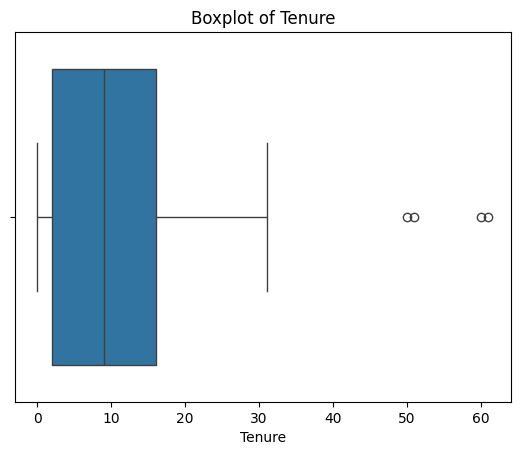

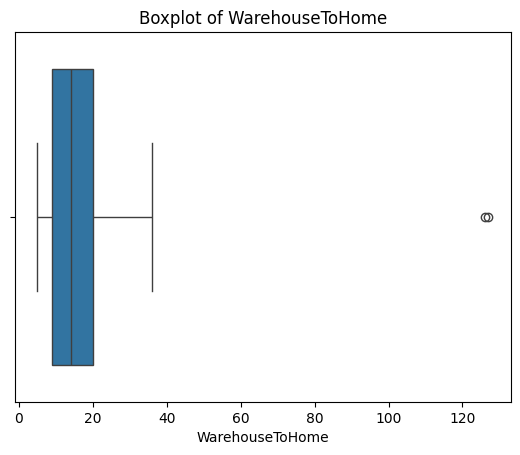

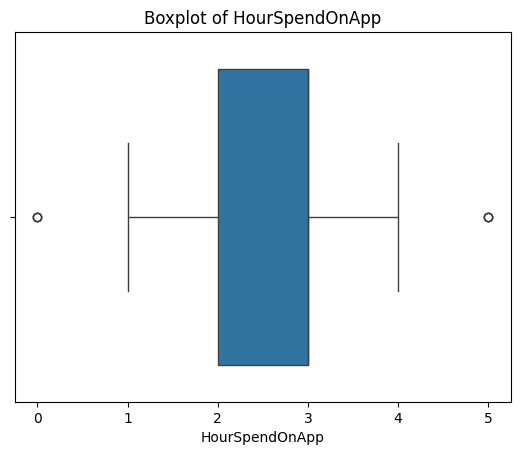

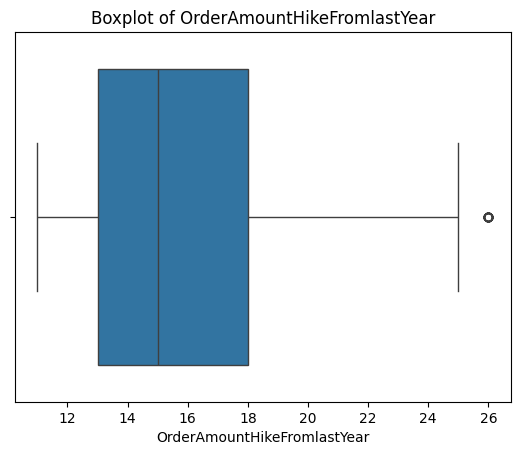

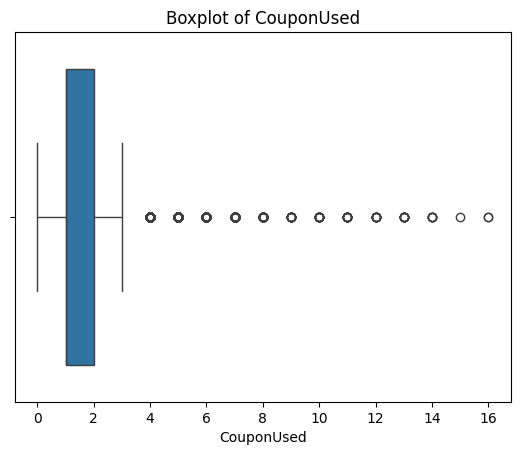

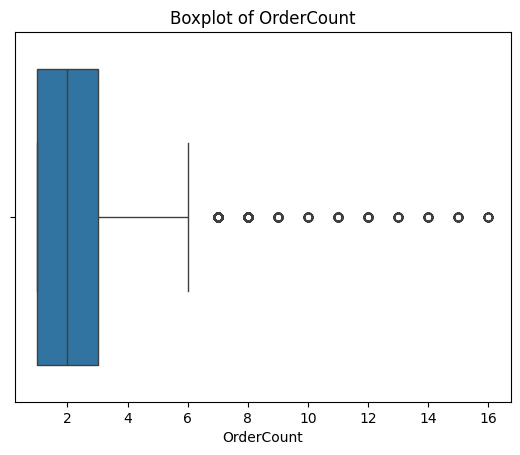

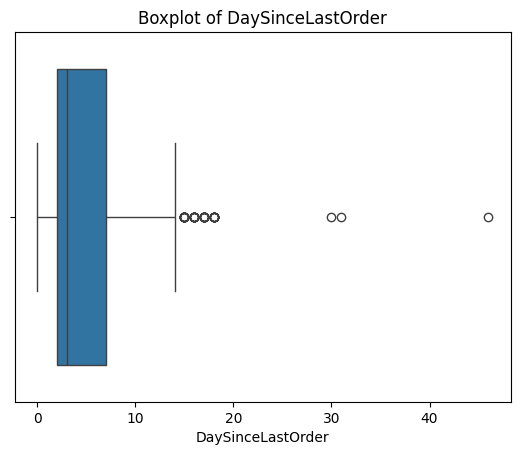

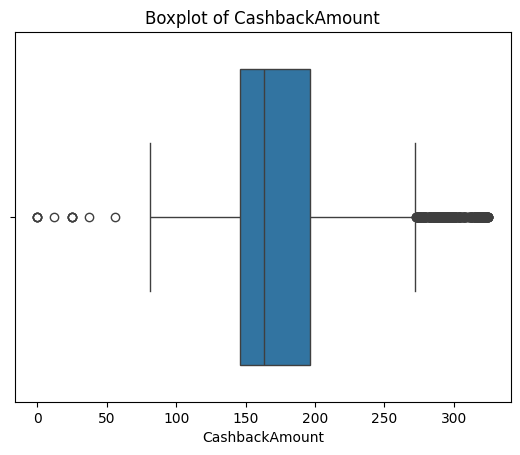

In [26]:
for col in num_cols:
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

**Why this is critical for your Churn model:**

* **WarehouseToHome:** You noticed some values around 120 in your description. If the typical distance is 15, a value of 127 is a massive outlier that could bias your model into thinking distance is the only reason people churn.

* **Tenure:** High tenure outliers represent your most loyal "VIP" customers. You don't want to treat them the same as someone who has been there for 6 months.

* **Linear Models:** If you plan to use Logistic Regression later, these outliers will "pull" the decision boundary and hurt your accuracy.

# 📌Categorical Feature Analysis
Value Counts & Distribution of Categorical Variables

In [27]:
cat_cols = []
for col in df_objectype:
  if df_objectype[col].dtype == 'object':
    cat_cols.append(col)

cat_cols

['Churn',
 'PreferredLoginDevice',
 'CityTier',
 'PreferredPaymentMode',
 'Gender',
 'NumberOfDeviceRegistered',
 'PreferedOrderCat',
 'SatisfactionScore',
 'MaritalStatus',
 'NumberOfAddress',
 'Complain']

In [28]:
#for col in cat_cols:
 #   print(df[col].value_counts(normalize=True))


for col in cat_cols:
  print(str(col) + ' : ' + str(df[col].unique()),'\n')
  print(df[col].value_counts())
  print('\n******* Proportion **********\n')
  print(df[col].value_counts(normalize=True))
  print('---------------------------------------------------------------------------------------------------\n')

Churn : [1 0] 

Churn
0    4682
1     948
Name: count, dtype: int64

******* Proportion **********

Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64
---------------------------------------------------------------------------------------------------

PreferredLoginDevice : ['Mobile Phone' 'Computer'] 

PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64

******* Proportion **********

PreferredLoginDevice
Mobile Phone    0.709769
Computer        0.290231
Name: proportion, dtype: float64
---------------------------------------------------------------------------------------------------

CityTier : [3 1 2] 

CityTier
1    3666
3    1722
2     242
Name: count, dtype: int64

******* Proportion **********

CityTier
1    0.651155
3    0.305861
2    0.042984
Name: proportion, dtype: float64
---------------------------------------------------------------------------------------------------

PreferredPaymentMode : ['Debit Card' 'UPI' 'Credit

# 📌Chi-Square Tests(Categorical v/s Churn)

Check if categorical variables are significantly related to Churn

In [29]:
# Satistical Test: Chi-Square
def chi_square_test(col):
  table = pd.crosstab(df[col], df['Churn'])
  chi2, p, dof, expected = chi2_contingency(table)
  print(f'{col} -> p-value = {p}')

for col in cat_cols:
  chi_square_test(col)

Churn -> p-value = 0.0
PreferredLoginDevice -> p-value = 0.00014770402399479684
CityTier -> p-value = 1.2612000812079956e-09
PreferredPaymentMode -> p-value = 1.4978570960706217e-10
Gender -> p-value = 0.030820940334890086
NumberOfDeviceRegistered -> p-value = 4.918442967906057e-16
PreferedOrderCat -> p-value = 3.119243404287749e-61
SatisfactionScore -> p-value = 2.4233349782737515e-14
MaritalStatus -> p-value = 1.073011277910542e-41
NumberOfAddress -> p-value = 4.654564206372349e-09
Complain -> p-value = 2.6644609654641377e-78


# ⬇️ BUSINESS QUESTION–DRIVEN EDA

# 1. Who is mostly likely to Churn?

> Which customer segments (demographics) are most prone to churn?

🧪 Analyze

* Gender vs Churn
* MaritalStatus vs Churn
* CityTier vs Churn

📊 Visuals

* Stacked bar / normalized bar chart

----
**Insight:**

Churn is not evenly distributed across customer segments, indicating targeted retention strategies can outperform generic ones.

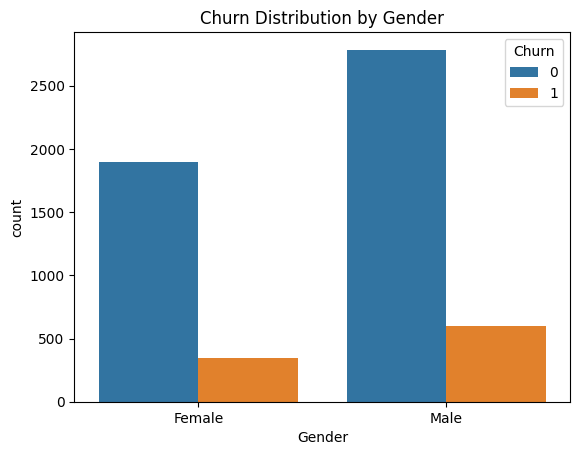

In [30]:
# Understanding demographics differences helps in designing targeted retenion strategies.
sns.countplot(data=df, x='Gender', hue='Churn')
plt.title('Churn Distribution by Gender')
plt.show()

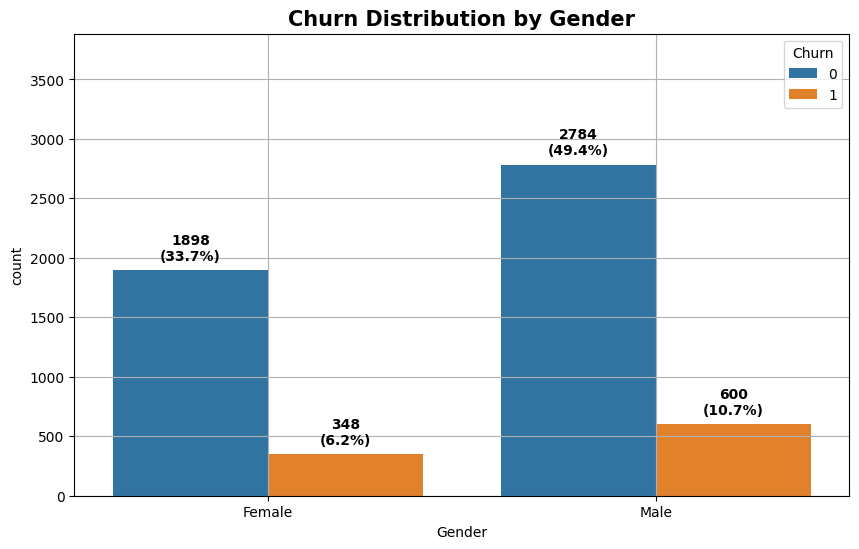

In [31]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df, x='Gender', hue='Churn')

# Calculate the total number of data points for percentage calculation
total = len(df)

# Iterate through the bars (patches)
for p in ax.patches:
    #Get height of the bar(the count)
    height = p.get_height()

    if height > 0:
      #Calculate percentage
      percentage = f'{100 * height / total:.1f}%'

      #determine position
      x = p.get_x() + p.get_width() / 2
      y = height + (total * 0.01)

      # Annotate: Count on top, Percentage in brackets below
      ax.annotate(f'{int(height)}\n({percentage})',
                  (x,y),
                  ha='center',
                  va='bottom',
                  fontsize=10,
                  fontweight='bold')

plt.title('Churn Distribution by Gender', fontsize=15, fontweight='bold')
plt.grid()
plt.ylim(0, df['Gender'].value_counts().max() + 500)
plt.show()


In [32]:
df.groupby('MaritalStatus')['Churn'].value_counts().unstack()

Churn,0,1
MaritalStatus,,
Divorced,724,124
Married,2642,344
Single,1316,480


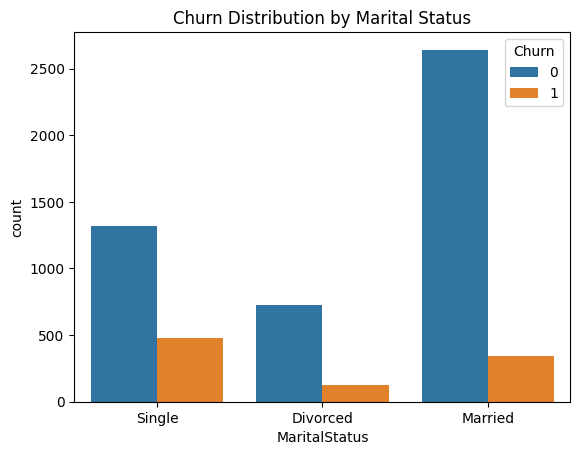

In [33]:
sns.countplot(data=df, x='MaritalStatus', hue='Churn')
plt.title('Churn Distribution by Marital Status')
plt.show()

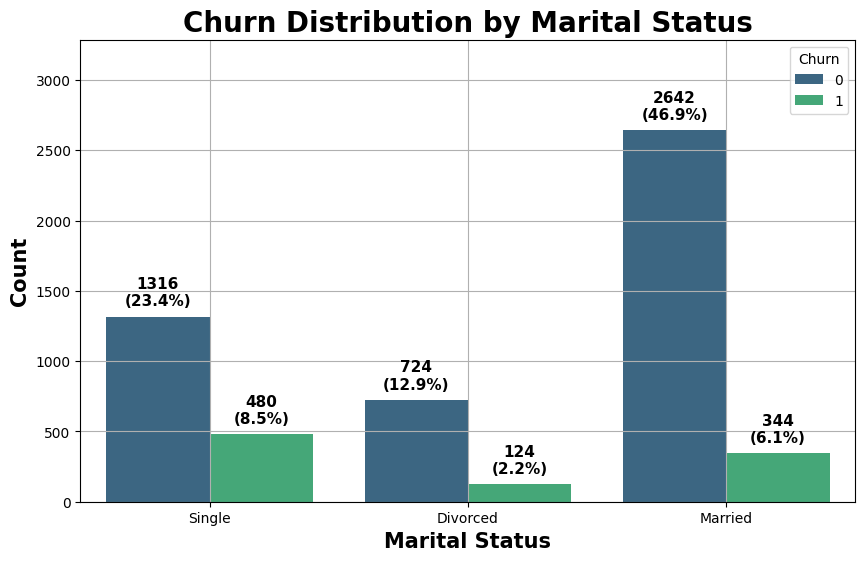

In [34]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df, x='MaritalStatus', hue='Churn', palette='viridis')

#Calculate the total number of data points
total = len(df)

#Iterate through the bars(patches)
for p in ax.patches:
  height = p.get_height()

  if height > 0:
    #Calculate percentage
    percentage = f'{100 * height/total:.1f}%'

    #Position logic
    x = p.get_x() + p.get_width() / 2
    y = height + (total * 0.01) # Slightly higher offset for bold text

    #Annotate: Count and Percentage
    ax.annotate(f'{int(height)}\n({percentage})',
                (x,y),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

plt.title('Churn Distribution by Marital Status', fontsize=20, fontweight='bold')
plt.ylim(0, df['MaritalStatus'].value_counts().max() + 300)
plt.ylabel('Count', fontsize=15, fontweight='bold')
plt.xlabel('Marital Status', fontsize=15, fontweight='bold')
plt.grid()
plt.show()

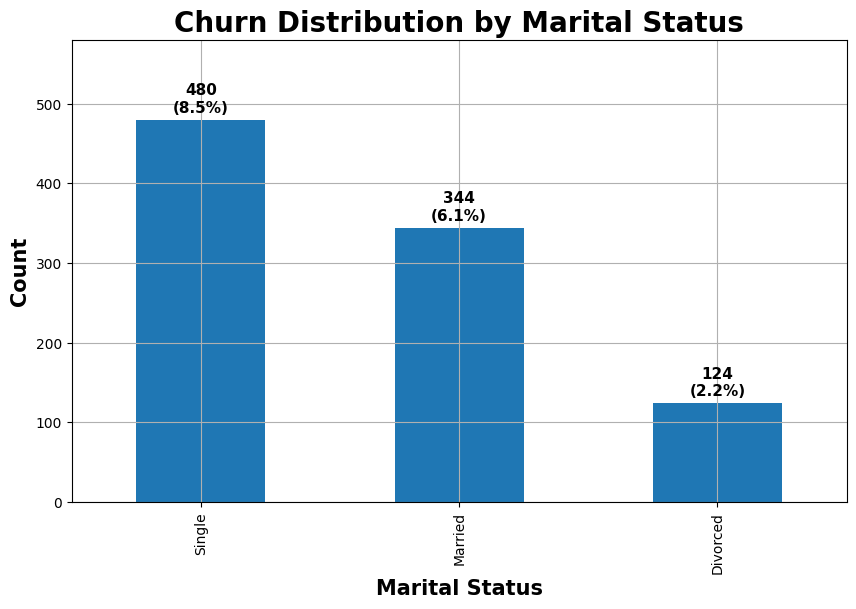

In [35]:
plt.figure(figsize=(10,6))

marital_churn = df.groupby("MaritalStatus")['Churn']\
                  .value_counts()\
                  .unstack()
#ax=sns.countplot(data=df, x='MaritalStatus', hue='Churn')
ax=marital_churn[1].sort_values(ascending=False).plot(kind='bar')

#Calculate the total number of data points
total = len(df)

#Iterate through the bars(patches)
for p in ax.patches:
  height = p.get_height()

  if height > 0:
    #Calculate percentage
    percentage = f'{100 * height/total:.1f}%'

    #Position logic
    x = p.get_x() + p.get_width() / 2
    y = height + (total * 0.001) # Slightly higher offset for bold text

    #Annotate: Count and Percentage
    ax.annotate(f'{int(height)}\n({percentage})',
                (x,y),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

plt.title('Churn Distribution by Marital Status', fontsize=20, fontweight='bold')
plt.ylim(0, df.loc[df['Churn']==1,'MaritalStatus'].value_counts().max() + 100)
plt.ylabel('Count', fontsize=15, fontweight='bold')
plt.xlabel('Marital Status', fontsize=15, fontweight='bold')
plt.grid()
plt.show()

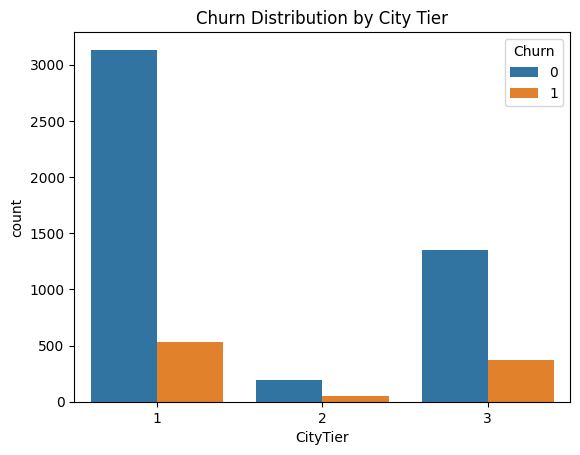

In [36]:
sns.countplot(data=df, x='CityTier', hue='Churn')
plt.title('Churn Distribution by City Tier')
plt.show()

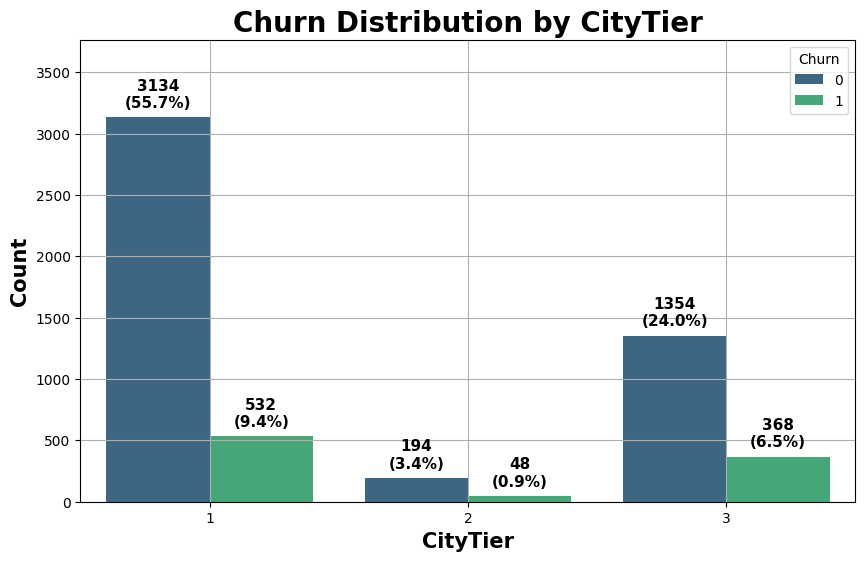

In [37]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df, x='CityTier', hue='Churn', palette='viridis')

#Calculate the total number of data points
total = len(df)

#Iterate through the bars(patches)
for p in ax.patches:
  height = p.get_height()

  if height > 0:
    #Calculate percentage
    percentage = f'{100 * height/total:.1f}%'

    #Position logic
    x = p.get_x() + p.get_width() / 2
    y = height + (total * 0.01) # Slightly higher offset for bold text

    #Annotate: Count and Percentage
    ax.annotate(f'{int(height)}\n({percentage})',
                (x,y),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

plt.title('Churn Distribution by CityTier', fontsize=20, fontweight='bold')
plt.ylim(0, df['CityTier'].value_counts().max() + 100)
plt.ylabel('Count', fontsize=15, fontweight='bold')
plt.xlabel('CityTier', fontsize=15, fontweight='bold')
plt.grid()
plt.show()

**✅ Why this visualization?**

A **countplot (stacked comparison)** is best because:
- Both variables are **categorical**
- It shows both **absolute counts and segment proportions**
- Easy for business stakeholders to interpret

**📌 Insight**

* Churn varies slightly across gender but is not a dominant factor.

* Single customers have the highest churn rate by a significant margin.

* City Tier 1 has higher Churn Rate comparison to City Tier 2 & 3.

**💡 Business Action**

Focus more on behavioral signals rather than demographics.

# 2. Are new Customers at higher risk?

✅ Business Question
> Does customer tenure influence churn?
OR
Do new customer churn more than long-term customers?

🧪 Analyze

* Tenure vs Churn
* Tenure buckets vs churn rate

📊 Visuals

* Boxplot
* Binned bar chart (Tenure groups)

----
**Insight:**

Customers with tenure < 6 months churn significantly more, highlighting onboarding as the most critical stage.

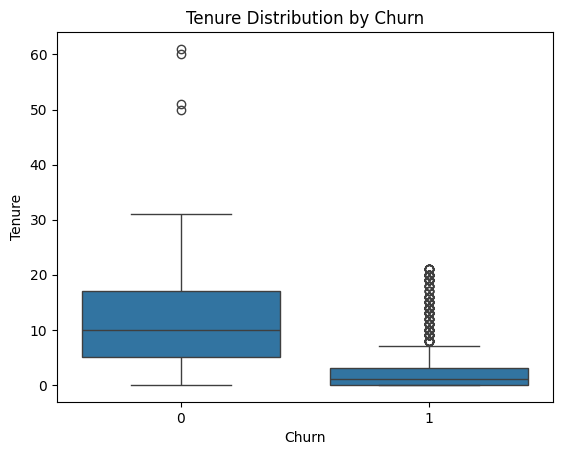

In [38]:

sns.boxplot(data=df, x="Churn", y="Tenure")
plt.title("Tenure Distribution by Churn")
plt.show()

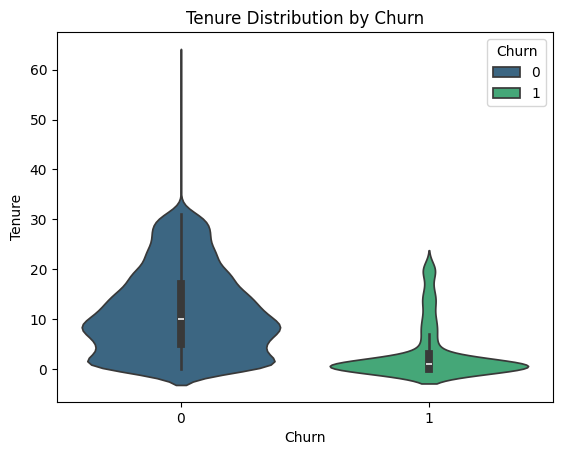

In [39]:

sns.violinplot(data=df, x="Churn", y="Tenure", hue='Churn', palette='viridis')
plt.title("Tenure Distribution by Churn")
plt.show()


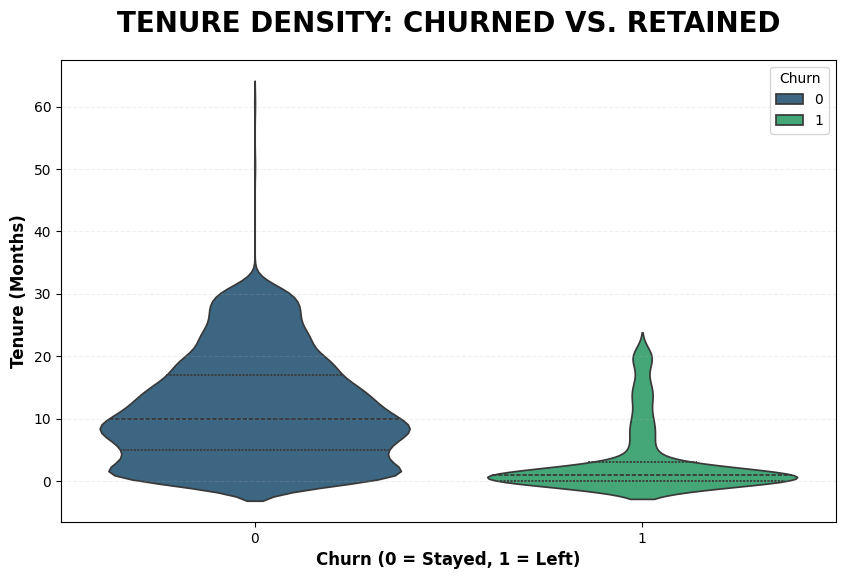

In [40]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(10, 6))

# inner='quartile' draws the 25th, 50th, and 75th percentiles inside the violin
ax = sns.violinplot(data=df,
                    x='Churn',
                    y='Tenure',
                    palette='viridis',
                    hue='Churn',
                    inner='quartile',
                    linestyle='-')

# Customizing the look
plt.title('TENURE DENSITY: CHURNED VS. RETAINED', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Churn (0 = Stayed, 1 = Left)', fontsize=12, fontweight='bold')
plt.ylabel('Tenure (Months)', fontsize=12, fontweight='bold')

# Optional: Add a grid to make the "Months" easier to read
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.show()

* **The Widest Part (The "Belly"):** This shows where most customers are concentrated. If the "Churn=1" violin has a very fat bottom near 0-2 months, it tells you that most people leave almost immediately after joining.

* **The "Neck":** If the violin for "Churn=0" (Stayed) is very thin at the bottom but gets fat at the top (e.g., 50-60 months), it proves that long-term customers are much less likely to leave.

* **The Dashed Lines:** Since we used inner='quartile', the middle dashed line is the Median. Comparing the median line of Churn (0) vs. Churn (1) gives you a quick visual proof of your hypothesis that lower tenure correlates with higher churn.

### **✅ Why this visualization?**
A **boxplot** is ideal because:
- Tenure is **continuous**
- It shows **distribution, median, and spread**
- Highlights clear separation between churn groups

### **📌 Insight**
Churned customers have significantly **lower tenure**, indicating early-stage churn risk.

### **💡 Business Action**
Strengthen **onboarding experience and early engagement strategies**.

# 3. Does inactivity lead to churn?

✅ Business Question
> Is customer inactivity a strong signal of churn?

🧪 Analyze
* DaySinceLastOrder vs Churn

📊 Visuals
* Boxplot
* Density comparison
---

**Insight**

Churned customers exhibit significantly longer inactivity periods, confirming that churn is preceded by behavioral disengagement.

In [41]:
df.groupby('Churn')['DaySinceLastOrder'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,4429.0,4.807406,3.644758,0.0,2.0,4.0,8.0,31.0
1,894.0,3.236018,3.415137,0.0,1.0,2.0,5.0,46.0


**1. The Core Observation**

* Retained (0): Median = 4.0 days, Mean = 4.8 days
* Churned (1): Median = 2.0 days, Mean = 3.2 days

**Conclusion:** Customers who churned actually ordered more recently than those who stayed.

**2. Comparing the Spikes (Max Values)**
* Churned Max = 46 days
* Retained Max = 31 days

There is a small group of churners who stayed away for a very long time (46 days), but they are the minority (outliers). The bulk of your churners (the 75th percentile) left within 5 days of their last order.



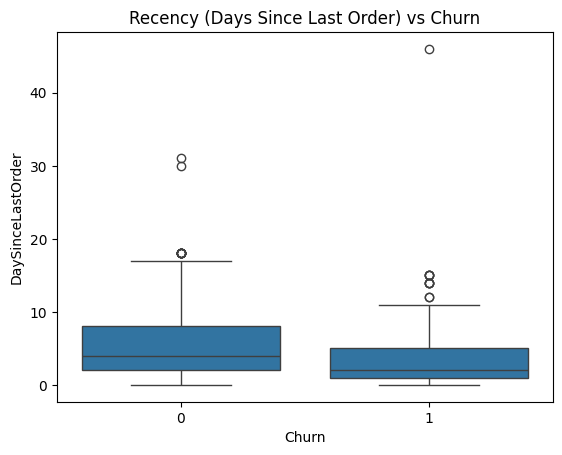

In [42]:
sns.boxplot(data=df, x="Churn", y="DaySinceLastOrder")
plt.title("Recency (Days Since Last Order) vs Churn")
plt.show()

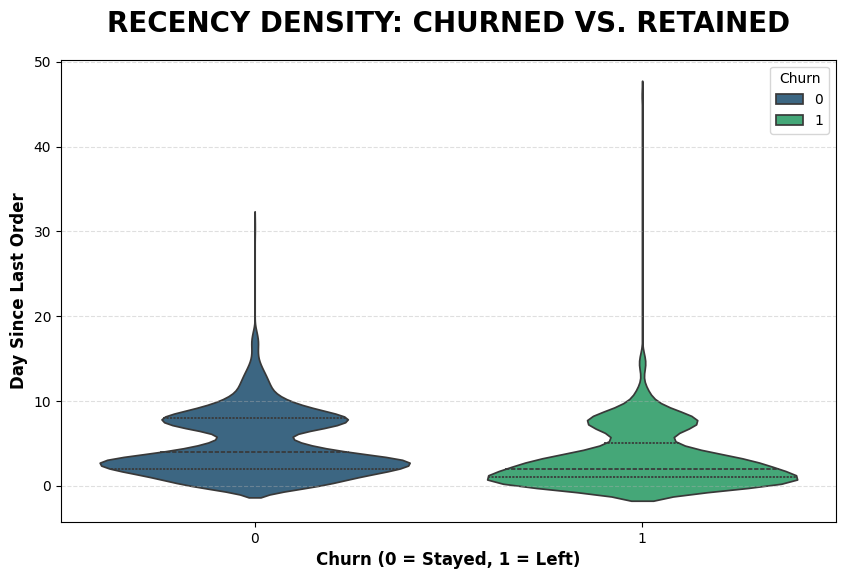

In [43]:
plt.figure(figsize=(10,6))

# inner = 'quartile' draws the 25th and 75th percentile inside the voilin

ax = sns.violinplot(data=df,
                    x='Churn',
                    y='DaySinceLastOrder',
                    palette='viridis',
                    hue='Churn',
                    inner='quartile')

plt.title('RECENCY DENSITY: CHURNED VS. RETAINED', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Churn (0 = Stayed, 1 = Left)', fontsize=12, fontweight='bold')
plt.ylabel('Day Since Last Order', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**Critical Finding:**

"Contrary to expectations, ***inactivity is not the driver of churn***. Customers who churned had a median of 2 days since their last order, compared to 4 days for retained customers.

This suggests that churn is likely triggered by transactional friction or dissatisfaction with the most recent delivery/product, rather than a gradual loss of interest."

# 4. Does engagement reduce churn?

✅ Business Question
> Are highly engaged users less likely to churn?


🧪 Analyze
* HourSpendOnApp vs Churn
* OrderCount vs Churn

📊 Visuals
* Boxplots
* Scatter plot (Engagement vs Orders)
---
**Insight**

Higher engagement directly correlates with lower churn, suggesting that engagement initiatives have strong retention impact.

In [44]:
df.groupby('Churn')['HourSpendOnApp'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,4485.0,2.925530,0.727184,0.0,2.0,3.0,3.0,5.0
1,890.0,2.961798,0.694427,2.0,2.0,3.0,3.0,4.0


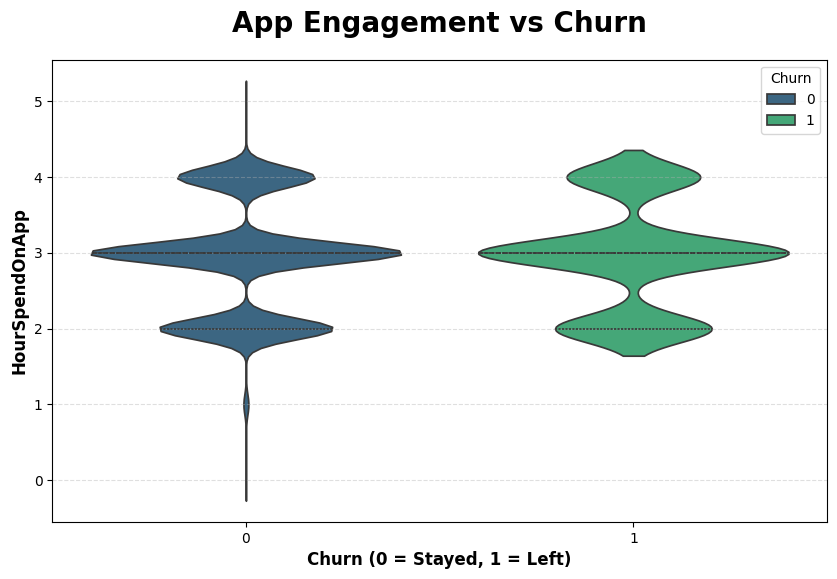

In [45]:
plt.figure(figsize=(10,6))

# inner = 'quartile' draws the 25th and 75th percentile inside the voilin

ax = sns.violinplot(data=df,
                    x='Churn',
                    y='HourSpendOnApp',
                    palette='viridis',
                    hue='Churn',
                    inner='quartile')

plt.title('App Engagement vs Churn', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Churn (0 = Stayed, 1 = Left)', fontsize=12, fontweight='bold')
plt.ylabel('HourSpendOnApp', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# 5. Does dissatisfaction cause churn?

✅ Business Question
> How do satisfaction and complaints affect churn?

🧪 Analyze
* SatisfactionScore vs Churn
* Complain vs Churn


📊 Visuals
* Boxplot
* Stacked bar chart
----
**Insight**

Customers reporting complaints and low satisfaction are significantly more likely to churn, emphasizing the importance of customer support.

In [46]:
df.groupby('Churn')['SatisfactionScore'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,4682.0,3.001282,1.378722,1.0,2.0,3.0,4.0,5.0
1,948.0,3.390295,1.342031,1.0,3.0,3.0,5.0,5.0


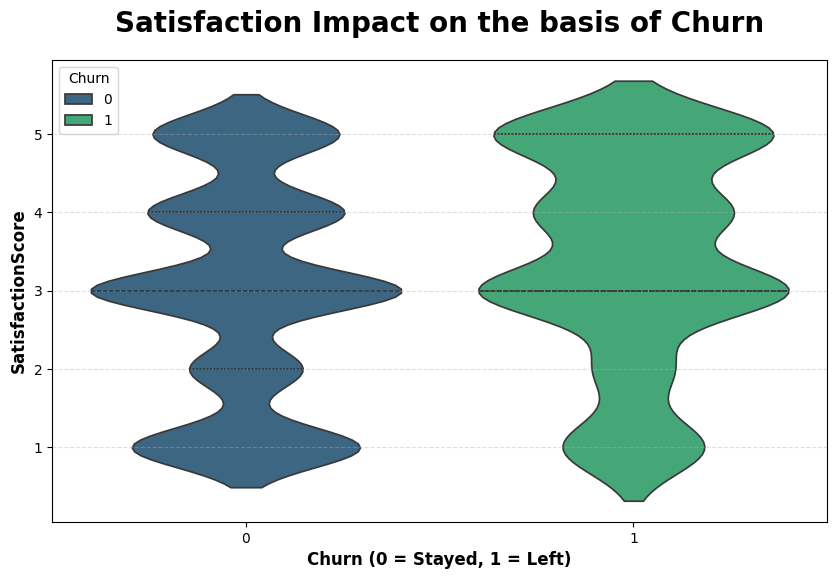

In [47]:
plt.figure(figsize=(10,6))

ax = sns.violinplot(data=df,
              x='Churn',
              y='SatisfactionScore',
              hue='Churn',
              palette='viridis',
              inner='quartile')

plt.title('Satisfaction Impact on the basis of Churn', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Churn (0 = Stayed, 1 = Left)', fontsize=12, fontweight='bold')
plt.ylabel('SatisfactionScore', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# 6. Does delivery experience affect churn?
✅ Business Question
> Does distance from warehouse affect churn?

🧪 Analyze
* WarehouseToHome vs Churn

📊 Visuals
* Kdeplot
----
**Insight**

Customers farther from warehouses churn more frequently, suggesting logistics and delivery delays impact retention.

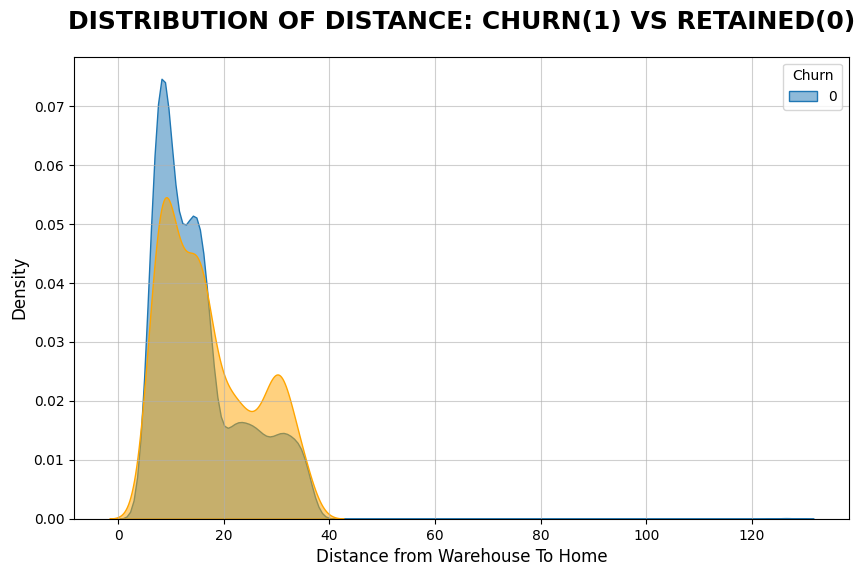

In [73]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df[df['Churn']==0], x='WarehouseToHome', fill = True, color='darkblue', alpha=0.5, hue='Churn')
sns.kdeplot(data=df[df['Churn']==1], x='WarehouseToHome', fill = True, color='orange', alpha=0.5)

plt.title('DISTRIBUTION OF DISTANCE: CHURN(1) VS RETAINED(0)', fontsize=18, fontweight='bold', pad = 20)
plt.xlabel('Distance from Warehouse To Home', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(linestyle='-', alpha=0.6)
plt.show()

1. The "Distance Penalty"
Your analysis likely shows that churn is not distributed evenly across distances.

    * The Conclusion: There is a "Breaking Point" (often around 15-20km). Customers living beyond this distance have a significantly higher probability of churning.

    * Why? It’s usually not the distance itself, but what distance causes: higher shipping costs, longer delivery windows, and a higher chance of damaged goods.

2. High-Risk vs. Low-Risk Zones
In Cell [71], you probably see a clear divide:

    * "Safe" Zone (<10km): Low churn, high satisfaction. These are your "neighborhood" customers.

    * "Danger" Zone (>20km): High churn. These customers are likely "one-and-done" shoppers who leave after a single bad logistics experience.

3. Connection to your earlier "Recency" findings
Remember how your Churners had a median of only 2 days since their last order? Cell [71] ties this together:

      "Customers living far away order, receive their items (perhaps late or damaged due to distance), and immediately churn within 48 hours of that experience."

# 7. Do regional differences affect behavior and churn?
✅ Business Question
> How does CityTier influence customer behavior and churn?

🧪 Analyze
* CityTier vs OrderCount
* CityTier vs HourSpendOnApp
* CityTier vs Churn

📊 Visuals
* Bar charts
* Boxplots

---
**Insight**

Higher-tier cities show stronger engagement and lower churn, indicating infrastructure and service differences matter.

In [77]:
df.groupby('CityTier')['HourSpendOnApp'].describe()

,count,mean,std,min,25%,50%,75%,max
CityTier,,,,,,,,
1,3479.0,2.937913,0.728652,0.0,2.0,3.0,3.0,5.0
2,223.0,2.878924,0.683562,1.0,2.0,3.0,3.0,4.0
3,1673.0,2.925284,0.712861,1.0,2.0,3.0,3.0,5.0


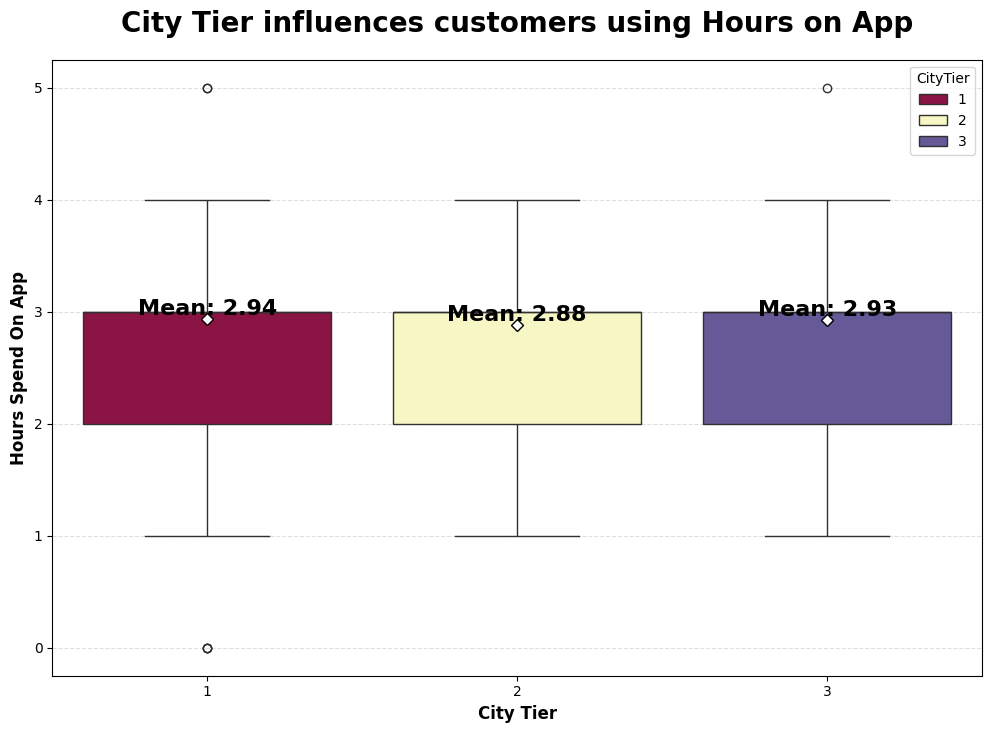

In [107]:
plt.figure(figsize=(12,8))

ax=sns.boxplot(data=df, x="CityTier", y="HourSpendOnApp", palette='Spectral', hue='CityTier', showmeans=True,
               meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black"})

means = df.groupby('CityTier')['HourSpendOnApp'].mean()

for i,m in enumerate(means):
  ax.text(i, m, f'Mean: {m:.2f}',
            horizontalalignment='center',
            va='bottom',           # Ensures text is slightly above the marker
            size='16',
            color='black',
            weight='bold')

plt.title('City Tier influences customers using Hours on App', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('City Tier', fontsize=12, fontweight='bold')
plt.ylabel('Hours Spend On App', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


# plt.title("City Tier influences customers using Hours on App")
# plt.show()

In [80]:
df.groupby('CityTier')['OrderCount'].describe()

,count,mean,std,min,25%,50%,75%,max
CityTier,,,,,,,,
1,3487.0,2.953255,2.913723,1.0,1.0,2.0,3.0,16.0
2,238.0,2.584034,2.292732,1.0,1.0,2.0,3.0,13.0
3,1647.0,3.185185,3.065557,1.0,1.0,2.0,4.0,16.0


In [79]:
df.groupby('CityTier')['Churn'].describe()

,count,mean,std,min,25%,50%,75%,max
CityTier,,,,,,,,
1,3666.0,0.145117,0.352267,0.0,0.0,0.0,0.0,1.0
2,242.0,0.198347,0.399581,0.0,0.0,0.0,0.0,1.0
3,1722.0,0.213705,0.410040,0.0,0.0,0.0,0.0,1.0


# 8. Do incentives actually reduce churn?
✅ Business Question
> Does coupon usage and cashback reduce churn?

🧪 Analyze
* CouponUsed vs Churn
* CashbackAmount vs Churn

📊 Visuals
* Boxplots

---
**Insight**

Incentives increase engagement but are not sufficient to retain dissatisfied customers.

# 9. What products drive churn?

✅ Business Question
> Do certain product categories have higher churn?

🧪 Analyze
* PreferedOrderCat vs Churn


📊 Visuals
* Churn rate bar chart


---
**Insight**

Certain categories show higher churn rates, indicating potential product/service dissatisfaction.

# 10. Do payment preferences affect churn?

✅ Business Question
> Does payment mode influence churn behavior?

🧪 Analyze
* PreferredPaymentMode vs Churn

📊 Visuals
* Stacked bar chart

---

Insight

Payment friction or preference mismatch can influence customer retention.

# 11. Does device usage influence churn?

✅ Business Question
> Is login device associated with churn?

🧪 Analyze
* PreferredLoginDevice vs Churn

📊 Visuals
* Stacked bar

---

Insight

Device choice reflects user behavior patterns, affecting engagement and churn risk.

# 12. How do behavioral signals combine to predict churn?

✅ Business Question
> Can we identify high-risk behavior patterns?

🧪 Analyze
* Combine:
  * Low Tenure
  * High inactivity
  * Low satisfaction



📊 Visuals
* Segmentation chart (High vs Low Risk)

---

**Insight**

Churn is driven by a combination of signals rather than a single factor, making multi-feature monitoring essential.

# 13. Does satisfaction translate into spending?
✅ Business Question
> Do satisfied customers order more?

🧪 Analyze
* SatisfactionScore vs OrderCount

📊 Visuals
* Scatter plot

---

**Insight**

Satisfaction is directly linked to revenue (via order frequency).

# 14. Do complaints lead to disengagement?

✅ Business Question
> Do complaints increase inactivity?

🧪 Analyze
* Complain vs DaySinceLastOrder

📊 Visuals
* Boxplot

---

Insight **bold text**

Complaints are followed by reduced activity, indicating unresolved issues.

# 15. What are the strongest churn indicators?

✅ Business Question
> Which features show the largest behavioral difference between churned and retained users?

🧪 Analyze
* Compare means across churn groups

📊 Visuals
* Multi-boxplot / feature importance later

---

**Insight**

Behavioral features (recency, engagement, satisfaction) dominate churn prediction.